In [ ]:
from sklearn import datasets
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

# Load the Dataset
ds = datasets.load_wine()
x = ds.data  # independent variable
x.shape

(178, 13)

In [ ]:
import pandas as pd
x_df = pd.DataFrame(x, columns=ds.feature_names)
x_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
x_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: float64(13)
m

In [ ]:
x_df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [ ]:
x_df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

In [ ]:
x_df.duplicated().sum()

np.int64(0)

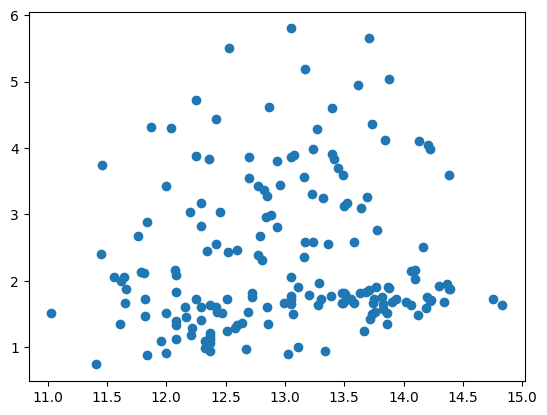

In [ ]:
plt.scatter(x[:,0], x[:,1])  # (x[:,0], x[:,1]) = (x[all rows, 1st column], x[all rows, 2nd column])
plt.show()

### K-Means with 2 Clusters

In [ ]:
cluster_2_model = KMeans(n_clusters=2)
cluster_labels = cluster_2_model.fit_predict(x[:,[0,1]])

cluster_labels[:10], cluster_labels[-10:]

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32),
 array([0, 1, 1, 0, 0, 1, 1, 1, 0, 1], dtype=int32))

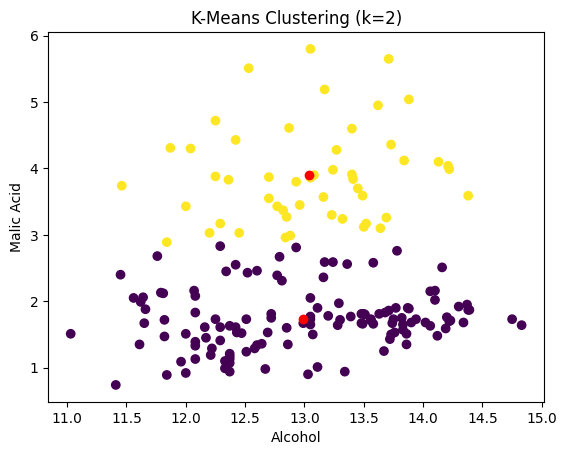

In [ ]:
cluster_2_model = KMeans(n_clusters=2)
cluster_labels = cluster_2_model.fit_predict(x[:,[0,1]])
plt.scatter(x[:,0], x[:,1], c=cluster_labels)
centroids = cluster_2_model.cluster_centers_
plt.scatter(centroids[:,0], centroids[:,1], c='red')
plt.title('K-Means Clustering (k=2)')
plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')
plt.show()

### K-Means with 3 Clusters

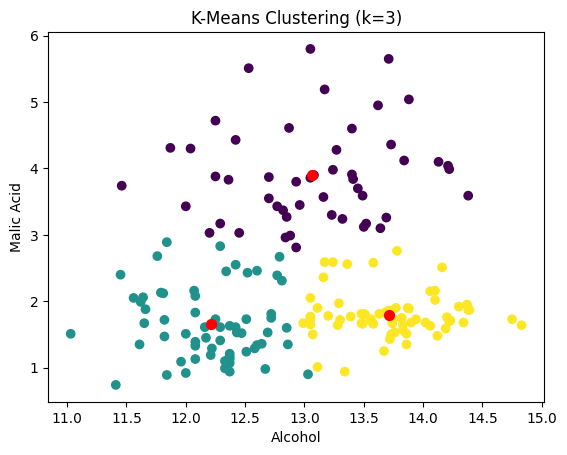

In [ ]:
cluster_3_model = KMeans(n_clusters=3)
cluster_labels = cluster_3_model.fit_predict(x[:,[0,1]])
plt.scatter(x[:,0], x[:,1], c=cluster_labels)
centroids = cluster_3_model.cluster_centers_
plt.scatter(centroids[:,0], centroids[:,1], s=50, color='red')
plt.title('K-Means Clustering (k=3)')
plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')
plt.show()

### Elbow Method to Find Best Value of k

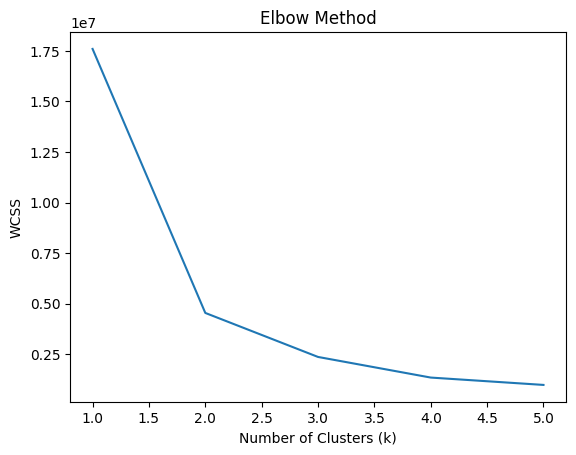

In [ ]:
# Using Elbow method to find best values of k
k_values = [1, 2, 3, 4, 5]
wcss_values = []

for k_value in k_values:
    model = KMeans(n_clusters=k_value)
    model.fit(x)
    wcss_value = model.inertia_
    wcss_values.append(wcss_value)

plt.plot(k_values, wcss_values)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

### Silhouette Score Comparison

In [ ]:
from sklearn.metrics import silhouette_score

k_values = [2, 3, 4, 5]
wcss_values = []

for k_value in k_values:
    model = KMeans(n_clusters=k_value)
    cluster_labels = model.fit_predict(x[:,[0, 1]])
    model_score = silhouette_score(x[:,[0,1]], cluster_labels)
    
    print(f"Cluster score: {model_score} for {k_value}")

Cluster score: 0.48134809606597634 for 2
Cluster score: 0.480535724062608 for 3
Cluster score: 0.4570166433007319 for 4
Cluster score: 0.37253379930065317 for 5


### Synthetic Blob Dataset for Visualization

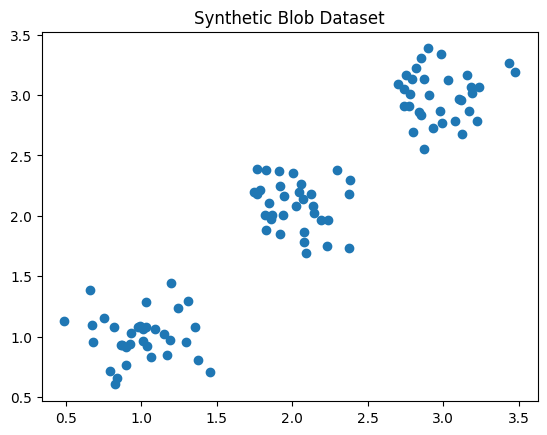

In [ ]:
x_data = datasets.make_blobs(n_samples=100, centers=[[1, 1], [2, 2], [3, 3]], cluster_std=0.2, random_state=0)
# x_data[0].shape
plt.scatter(x_data[0][:,0], x_data[0][:,1])
plt.title('Synthetic Blob Dataset')
plt.show()